# Community Alignment Exploratory

This notebook loads the full `community_alignment.csv`, filters rows to English only using `assigned_lang == 'en'`, and writes the result to `../data/community_alignment_en.csv`.

In [ ]:
from pathlib import Path
import pandas as pd

DATA_PATH = Path('../data/community_alignment.csv')
OUTPUT_PATH = Path('../data/community_alignment_en.csv')

df = pd.read_csv(DATA_PATH)
df_en = df[df['assigned_lang'] == 'en'].copy()
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
df_en.to_csv(OUTPUT_PATH, index=False)

print(f'Input rows: {len(df):,}')
print(f'English rows: {len(df_en):,}')
print(f'Saved: {OUTPUT_PATH}')


## Analysis

In [1]:
import pandas as pd

EN_DATA_PATH = '../data/community_alignment_en.csv'
DEMOGRAPHIC_COLUMNS = [
    'annotator_age',
    'annotator_gender',
    'annotator_education_level',
    'annotator_political',
    'annotator_ethnicity',
    'annotator_country',
]

DEMOGRAPHIC_LABEL_ORDER = {
    'annotator_age': [
        '18-34',
        '35-45',
        '46-54',
        '55+',
    ],
    'annotator_gender': [
        'female',
        'male',
        'other',
    ],
    'annotator_education_level': [
        '(At most) Complete Secondary',
        'Some post-secondary',
        'Post-secondary graduate',
        'Some or complete graduate degree',
        'Other',
    ],
    'annotator_political': [
        'Very right-leaning',
        'Somewhat right-leaning',
        'Middle-of-the-road, centrist',
        'Somewhat left-leaning',
        'Very left-leaning',
        'Prefer not to say',
        'I don’t think of myself in this way',
    ],
    'annotator_ethnicity': [
        'Indo-Aryan',
        'Dravidian',
        'White',
        'Black or African American',
        'Asian',
        'Hispanic or Latino',
        'Other',
        'Prefer not to say',
    ],
    'annotator_country': [
        'india',
        'united states',
    ],
}

def ordered_labels_for_column(column):
    return DEMOGRAPHIC_LABEL_ORDER.get(column, [])

df_en = pd.read_csv(EN_DATA_PATH)
is_first_prompt_true = df_en['is_pregenerated_first_prompt'].astype(str).str.lower().eq('true')
df = df_en[is_first_prompt_true].copy()

print(f'Total rows in English dataset: {len(df_en):,}')
print(f'Rows where is_pregenerated_first_prompt is True: {len(df):,}')


Total rows in English dataset: 22,168
Rows where is_pregenerated_first_prompt is True: 22,168


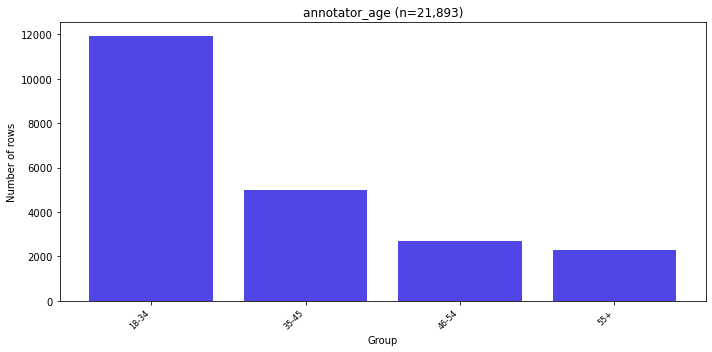

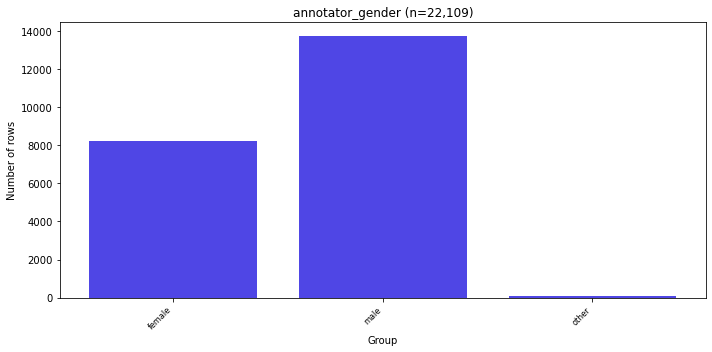

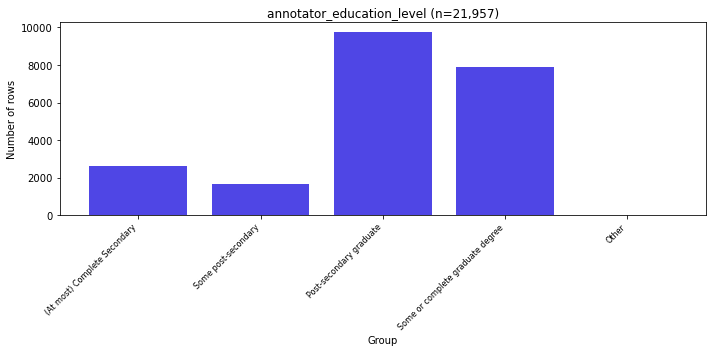

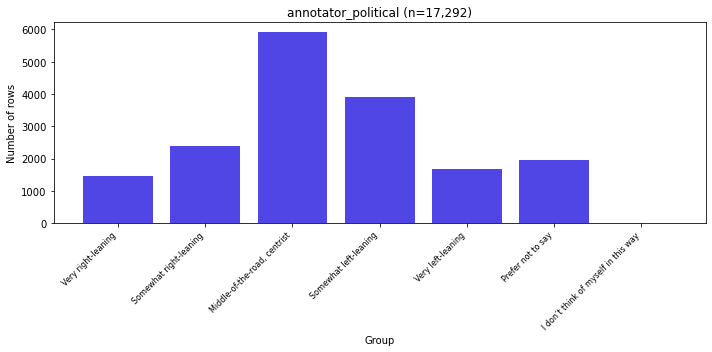

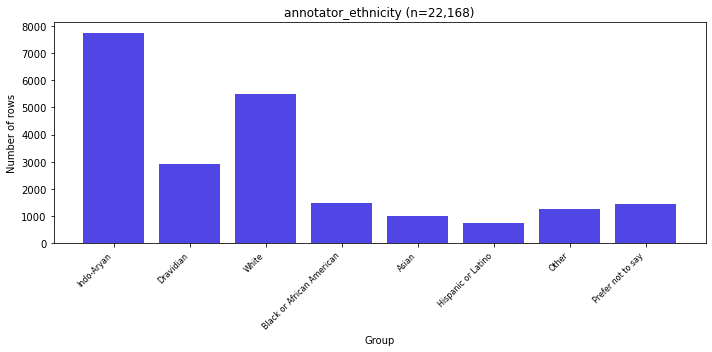

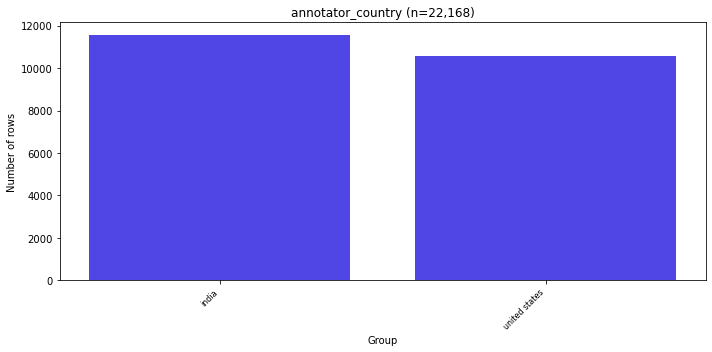

In [2]:
import matplotlib.pyplot as plt

for column in DEMOGRAPHIC_COLUMNS:
    if column not in df.columns:
        print(f'{column}: column not found')
        continue

    ordered_labels = ordered_labels_for_column(column)
    if not ordered_labels:
        print(f'{column}: no predefined label ordering found; skipping')
        continue

    group_counts = (
        df[column]
        .where(df[column].isin(ordered_labels))
        .value_counts()
        .reindex(ordered_labels, fill_value=0)
    )

    plt.figure(figsize=(10, 5))
    plt.bar(group_counts.index.astype(str), group_counts.values, color='#4F46E5')
    plt.title(f'{column} (n={int(group_counts.sum()):,})')
    plt.xlabel('Group')
    plt.ylabel('Number of rows')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.tight_layout()
    plt.show()


Number of first_turn_prompt groups: 1,033
Groups with at least 10 rows: 560


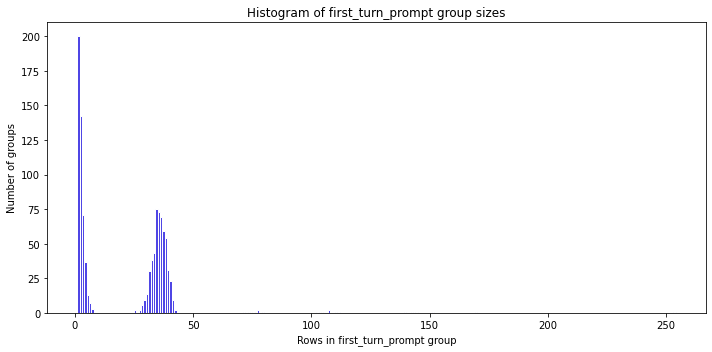

In [3]:
import matplotlib.pyplot as plt
import numpy as np

prompt_group_sizes = df.groupby('first_turn_prompt').size()
groups_with_at_least_10 = int((prompt_group_sizes >= 10).sum())

print(f'Number of first_turn_prompt groups: {len(prompt_group_sizes):,}')
print(f'Groups with at least 10 rows: {groups_with_at_least_10:,}')

if len(prompt_group_sizes):
    max_group_size = int(prompt_group_sizes.max())
    plt.figure(figsize=(10, 5))
    plt.hist(prompt_group_sizes.values, bins=range(1, max_group_size + 2), color='#4F46E5', edgecolor='white')
    plt.title('Histogram of first_turn_prompt group sizes')
    plt.xlabel('Rows in first_turn_prompt group')
    plt.ylabel('Number of groups')
    plt.tight_layout()
    plt.show()
else:
    print('No groups to plot.')


## Preference similarity by demographic group

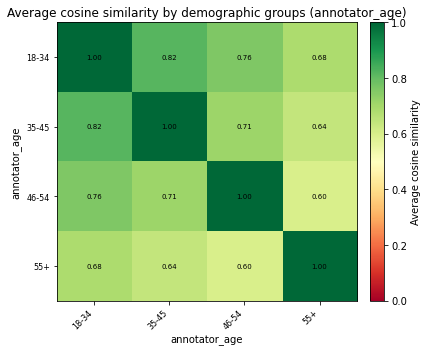

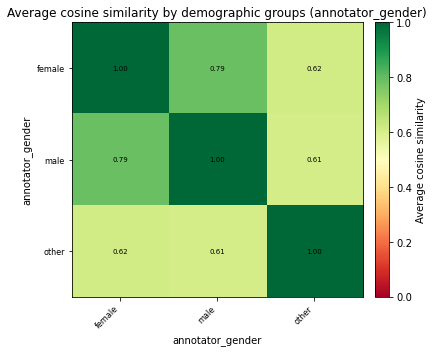

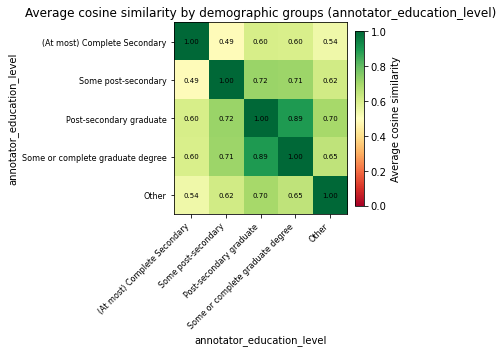

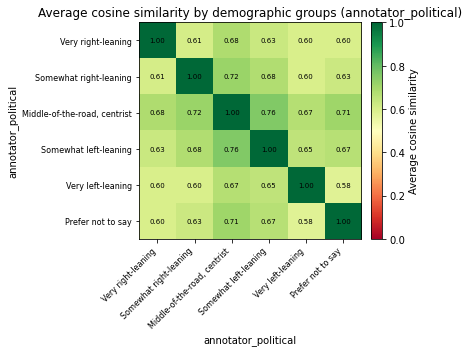

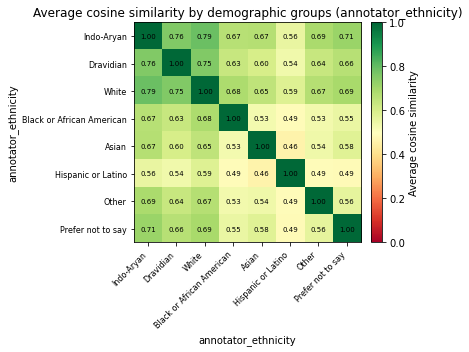

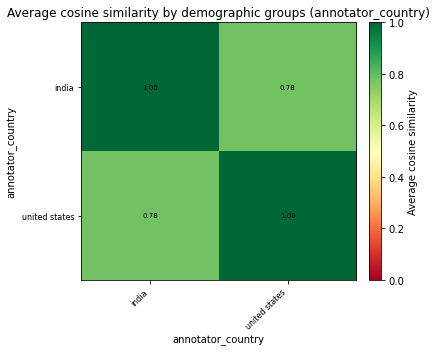

In [4]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

RESPONSE_OPTIONS = ['response_a', 'response_b', 'response_c', 'response_d']

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return 0.0
    return float(np.dot(a, b) / denom)

for column in DEMOGRAPHIC_COLUMNS:
    if column not in df.columns:
        print(f'[{column}] column missing from dataframe; skipping')
        continue

    ordered_labels = ordered_labels_for_column(column)
    if not ordered_labels:
        print(f'[{column}] no predefined label ordering found; skipping')
        continue

    df_tmp = df[['first_turn_prompt', column, 'first_turn_preferred_response']].copy()
    df_tmp = df_tmp[df_tmp[column].isin(ordered_labels)]
    df_tmp = df_tmp[df_tmp['first_turn_preferred_response'].isin(RESPONSE_OPTIONS)]

    observed_labels = [label for label in ordered_labels if label in set(df_tmp[column].dropna())]
    g = len(observed_labels)

    if g == 0:
        print(f'[{column}] no valid group labels; skipping')
        continue

    group_labels = observed_labels
    label_to_idx = {label: i for i, label in enumerate(group_labels)}

    sim_sum = np.zeros((g, g), dtype=float)
    sim_count = np.zeros((g, g), dtype=float)

    # Aggregate counts per (prompt, group, preferred_response)
    prompt_groups = (
        df_tmp
        .groupby(['first_turn_prompt', column, 'first_turn_preferred_response'])
        .size()
        .unstack('first_turn_preferred_response', fill_value=0)
        .reindex(columns=RESPONSE_OPTIONS, fill_value=0)
    )

    for _, prompt_df in prompt_groups.groupby(level=0):
        prompt_df = prompt_df.droplevel(0).astype(float)

        # Build normalized preference vectors for groups with non-zero rows in this prompt.
        group_vectors = {}
        for group_label, counts in prompt_df.iterrows():
            if group_label not in label_to_idx:
                continue
            total = counts.sum()
            if total > 0:
                group_vectors[group_label] = counts.to_numpy() / total

        active_groups = list(group_vectors.keys())
        if len(active_groups) == 0:
            continue

        # Self-similarity over prompts where group is present.
        for group_label in active_groups:
            gi = label_to_idx[group_label]
            sim_sum[gi, gi] += 1.0
            sim_count[gi, gi] += 1

        # Pairwise cross-group similarities for this prompt.
        for g1, g2 in itertools.combinations(active_groups, 2):
            sim = cosine_similarity(group_vectors[g1], group_vectors[g2])

            i = label_to_idx[g1]
            j = label_to_idx[g2]

            sim_sum[i, j] += sim
            sim_count[i, j] += 1
            sim_sum[j, i] += sim
            sim_count[j, i] += 1

    avg_similarity = np.full((g, g), np.nan, dtype=float)
    valid_mask = sim_count > 0
    avg_similarity[valid_mask] = sim_sum[valid_mask] / sim_count[valid_mask]

    cmap = plt.get_cmap('RdYlGn')
    if hasattr(cmap, 'with_extremes'):
        cmap = cmap.with_extremes(bad='lightgray')
    else:
        cmap = mcolors.ListedColormap(cmap(np.linspace(0, 1, 256)))
        cmap.set_bad(color='lightgray')

    fig_w = max(6, 0.5 * g)
    fig_h = max(5, 0.45 * g)
    plt.figure(figsize=(fig_w, fig_h))
    im = plt.imshow(avg_similarity, cmap=cmap, vmin=0, vmax=1, aspect='auto')
    plt.title(f'Average cosine similarity by demographic groups ({column})')
    plt.xlabel(column)
    plt.ylabel(column)
    ticks = np.arange(g)
    plt.xticks(ticks, group_labels, rotation=45, ha='right', fontsize=8)
    plt.yticks(ticks, group_labels, fontsize=8)
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label('Average cosine similarity')

    if g <= 25:
        for i in range(g):
            for j in range(g):
                if np.isfinite(avg_similarity[i, j]):
                    text_color = 'black'
                    if avg_similarity[i, j] < 0.35:
                        text_color = 'white'
                    plt.text(j, i, f'{avg_similarity[i, j]:.2f}', ha='center', va='center', color=text_color, fontsize=7)

    plt.tight_layout()
    plt.show()


## Top 10 polarizing prompts by demographic group

In [9]:
import base64
import io
import math
import re
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

POLARIZATION_HTML_PATH = Path('../data/top10_polarizing_prompts_by_demographic.html')

try:
    _ = cosine_similarity
except NameError:
    def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
        denom = np.linalg.norm(a) * np.linalg.norm(b)
        if denom == 0:
            return 0.0
        return float(np.dot(a, b) / denom)

RESPONSE_OPTIONS = ['response_a', 'response_b', 'response_c', 'response_d']
RESPONSE_TEXT_COLUMNS = [
    'first_turn_response_a',
    'first_turn_response_b',
    'first_turn_response_c',
    'first_turn_response_d',
]

missing_cols = [
    col for col in ['first_turn_prompt', 'first_turn_preferred_response', 'is_pregenerated_first_prompt'] if col not in df.columns
]
missing_cols += [
    col for col in RESPONSE_TEXT_COLUMNS if col not in df.columns
]

if missing_cols:
    print('Missing required columns in df:', ', '.join(missing_cols))
    raise ValueError('Required columns are missing from dataframe')

def _slugify(value: str) -> str:
    slug = re.sub(r'[^a-zA-Z0-9]+', '-', str(value).strip().lower())
    return slug.strip('-') or 'section'

def _safe_text(value) -> str:
    if pd.isna(value):
        return ''
    return str(value)

def _img_from_figure(fig) -> str:
    buffer = io.BytesIO()
    fig.savefig(buffer, format='png', dpi=160, bbox_inches='tight')
    plt.close(fig)
    encoded = base64.b64encode(buffer.getvalue()).decode('utf-8')
    return f'data:image/png;base64,{encoded}'

def _build_group_chart(group_labels, response_counts):
    if len(group_labels) == 0:
        return ''

    normalized_counts = []
    for counts in response_counts:
        values = np.array(counts, dtype=float)
        values = values[:4]
        if values.size < 4:
            values = np.pad(values, (0, 4 - values.size), constant_values=0)
        total = float(values.sum())
        normalized_counts.append((values / total if total > 0 else np.zeros_like(values)).tolist())

    x = np.arange(4)
    width = 0.8 / max(1, len(group_labels))
    center = (len(group_labels) - 1) / 2.0
    offsets = (np.arange(len(group_labels)) - center) * width
    fig, ax = plt.subplots(figsize=(4.8, 2.0))

    for idx, (group_label, counts) in enumerate(zip(group_labels, normalized_counts)):
        values = list(counts)
        values = values[:4]
        if len(values) < 4:
            values = values + [0.0] * (4 - len(values))
        ax.bar(x + offsets[idx], values, width=width, label=str(group_label))

    ax.set_xlabel('Response letter')
    ax.set_ylabel('Frac. of Selections')
    ax.set_xticks(x)
    ax.set_xticklabels(['a', 'b', 'c', 'd'])
    ax.set_title('Normalized response distribution by demographic group')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
    ax.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    return _img_from_figure(fig)



def _build_score_distribution_chart(scores, top_threshold):
    finite_scores = [float(v) for v in scores if isinstance(v, float) and not math.isnan(v)]
    if not finite_scores:
        return ''

    fig, ax = plt.subplots(figsize=(4.8, 2.0))
    ax.hist(np.clip(finite_scores, 0, 1), bins=np.linspace(0, 1, 21), color='#10b981', alpha=0.9, edgecolor='white')
    ax.set_xlim(0, 1)
    ax.set_title('Polarization score distribution', fontsize=10)
    ax.set_xlabel('Polarization score')
    ax.set_ylabel('Count')
    if top_threshold is not None and not math.isnan(top_threshold):
        clipped_threshold = max(0.0, min(1.0, float(top_threshold)))
        ax.axvline(clipped_threshold, color='#dc2626', linestyle='--', linewidth=1.5, label='Top-10 threshold')
        ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.2)
    plt.tight_layout()
    return _img_from_figure(fig)

prompt_response_texts = (
    df[['first_turn_prompt'] + RESPONSE_TEXT_COLUMNS]
    .drop_duplicates('first_turn_prompt', keep='first')
    .set_index('first_turn_prompt')
)

demographic_results = {}

for column in DEMOGRAPHIC_COLUMNS:
    if column not in df.columns:
        print(f'[{column}] missing from dataframe; skipping')
        continue

    ordered_labels = ordered_labels_for_column(column)
    if not ordered_labels:
        print(f'[{column}] no predefined labels found; skipping')
        continue

    required_dem_cols = [column, 'first_turn_prompt', 'first_turn_preferred_response']
    if any(col not in df.columns for col in required_dem_cols):
        missing = [col for col in required_dem_cols if col not in df.columns]
        print(f'[{column}] missing required columns: ' + ', '.join(missing) + '; skipping')
        continue

    df_tmp = df[['first_turn_prompt', column, 'first_turn_preferred_response']].copy()
    df_tmp = df_tmp[df_tmp[column].isin(ordered_labels)]
    df_tmp = df_tmp[df_tmp['first_turn_preferred_response'].isin(RESPONSE_OPTIONS)]

    if df_tmp.empty:
        print(f'[{column}] no rows after filtering; skipping')
        continue

    prompt_group = (
        df_tmp
        .groupby(['first_turn_prompt', column, 'first_turn_preferred_response'])
        .size()
        .unstack('first_turn_preferred_response', fill_value=0)
        .reindex(columns=RESPONSE_OPTIONS, fill_value=0)
    )

    if prompt_group.empty:
        print(f'[{column}] no grouped rows found; skipping')
        continue

    prompt_scores = []

    for prompt, prompt_df in prompt_group.groupby(level=0):
        prompt_df = (
            prompt_df.droplevel(0)
            .reindex(index=ordered_labels, columns=RESPONSE_OPTIONS, fill_value=0)
            .astype(float)
        )

        group_sizes = prompt_df.sum(axis=1)
        vectors = {}
        for group_name in ordered_labels:
            n = float(group_sizes.loc[group_name])
            if n > 0:
                vectors[group_name] = (prompt_df.loc[group_name].to_numpy() / n)

        numerator = 0.0
        denominator = 0.0

        for idx_left, left_group in enumerate(ordered_labels):
            left_size = float(group_sizes.loc[left_group])
            left_vec = vectors.get(left_group)
            if left_size <= 0 or left_vec is None:
                continue
            for right_group in ordered_labels[idx_left + 1:]:
                right_size = float(group_sizes.loc[right_group])
                right_vec = vectors.get(right_group)
                if right_size <= 0 or right_vec is None:
                    continue
                weight = left_size * right_size
                sim = cosine_similarity(left_vec, right_vec)
                numerator += weight * sim
                denominator += weight

        score = numerator / denominator if denominator > 0 else math.nan

        response_counts = []
        group_stats = []
        for group_name in ordered_labels:
            counts = prompt_df.loc[group_name].to_numpy()
            size = float(counts.sum())
            response_counts.append([int(x) for x in counts.tolist()])
            pref = (counts / size).tolist() if size > 0 else [0.0, 0.0, 0.0, 0.0]
            group_stats.append({
                'group': group_name,
                'size': int(size),
                'counts': [int(x) for x in counts.tolist()],
                'pref_vector': [round(float(x), 6) for x in pref],
            })

        responses = {
            'a': _safe_text(prompt_response_texts.loc[prompt, 'first_turn_response_a']) if prompt in prompt_response_texts.index else '',
            'b': _safe_text(prompt_response_texts.loc[prompt, 'first_turn_response_b']) if prompt in prompt_response_texts.index else '',
            'c': _safe_text(prompt_response_texts.loc[prompt, 'first_turn_response_c']) if prompt in prompt_response_texts.index else '',
            'd': _safe_text(prompt_response_texts.loc[prompt, 'first_turn_response_d']) if prompt in prompt_response_texts.index else '',
        }

        prompt_scores.append({
            'prompt': prompt,
            'score': score,
            'total_rows': int(group_sizes.sum()),
            'group_stats': group_stats,
            'response_counts': response_counts,
            'response_texts': responses,
        })

    valid_scores = [
        item for item in prompt_scores
        if item['total_rows'] >= 20 and not (isinstance(item['score'], float) and math.isnan(item['score']))
    ]
    valid_scores.sort(key=lambda item: item['score'])
    score_values = [item['score'] for item in valid_scores]
    top_prompt_scores = valid_scores[:10]
    top_10_threshold = top_prompt_scores[-1]['score'] if top_prompt_scores else None

    if not top_prompt_scores:
        print(f'[{column}] no valid polarizing prompts found; skipping')
        continue

    score_distribution_chart = _build_score_distribution_chart(score_values, top_10_threshold)

    cards = []
    for rank, prompt_entry in enumerate(top_prompt_scores, start=1):
        prompt_text = _safe_text(prompt_entry['prompt'])
        chart_data_uri = _build_group_chart(ordered_labels, prompt_entry['response_counts'])

        rows = []
        for group_info in prompt_entry['group_stats']:
            pref_vector_text = '[' + ', '.join(f'{value:.4f}' for value in group_info['pref_vector']) + ']'
            rows.append(
                '<tr>'
                f'<td>{escape(str(group_info["group"]) )}</td>'
                f'<td>{group_info["size"]}</td>'
                f'<td>{group_info["counts"][0]}, {group_info["counts"][1]}, {group_info["counts"][2]}, {group_info["counts"][3]}</td>'
                f'<td>{escape(pref_vector_text)}</td>'
                '</tr>'
            )

        cards.append(
            '<article class="prompt-card">'
            f'<h4>Rank #{rank} · Polarization score {prompt_entry["score"]:.6f}</h4>'
            f'<p class="prompt-text">{escape(prompt_text)}</p>'
            f'<p><strong>Prompt rows:</strong> {prompt_entry["total_rows"]}</p>'
            '<details class="response-details">'
            '<summary>Show responses</summary>'
            '<div class="response-texts">'
            f'<div><strong>Response a:</strong> {escape(prompt_entry["response_texts"]["a"]) or "(missing)"}</div>'
            f'<div><strong>Response b:</strong> {escape(prompt_entry["response_texts"]["b"]) or "(missing)"}</div>'
            f'<div><strong>Response c:</strong> {escape(prompt_entry["response_texts"]["c"]) or "(missing)"}</div>'
            f'<div><strong>Response d:</strong> {escape(prompt_entry["response_texts"]["d"]) or "(missing)"}</div>'
            '</div>'
            '</details>'
            '<table class="stats-table">'
            '<thead><tr><th>Demographic group</th><th>Group size</th><th>Counts [a, b, c, d]</th><th>Preference vector</th></tr></thead>'
            f'<tbody>{"".join(rows)}</tbody>'
            '</table>'
            f"<img src='{chart_data_uri}' alt='Group-by-response chart' class='chart'>"
            '</article>'
        )

    demographic_results[column] = {
        'ordered_labels': ordered_labels,
        'cards': cards,
        'score_distribution_chart': score_distribution_chart,
    }

nav_items = []
sections = []
for col_name in DEMOGRAPHIC_COLUMNS:
    if col_name not in demographic_results:
        continue

    anchor = f'demo-{_slugify(col_name)}'
    nav_items.append(f'<li><a href="#{anchor}">{escape(col_name)}</a></li>')

    payload = demographic_results[col_name]
    sections.append(f'<section class="group-section" id="{anchor}">')
    sections.append(f'<h2>{escape(col_name)}</h2>')
    sections.append(f"<img src='{payload['score_distribution_chart']}' alt='Score distribution' class='score-chart'>")
    sections.append('<div class="group-meta"><strong>Listed groups:</strong> ' + '; '.join([escape(x) for x in payload['ordered_labels']]) + '</div>')
    if not payload['cards']:
        sections.append('<p>No qualifying prompts available.</p>')
        sections.append('</section>')
        continue
    for card in payload['cards']:
        sections.append(card)
    sections.append('</section>')

html_parts = [
    '<!doctype html>',
    '<html>',
    '<head>',
    "<meta charset='utf-8'>",
    '<title>Top 10 Polarizing Prompts by Demographic Group</title>',
    '<style>',
    'body { font-family: Inter, Arial, sans-serif; margin: 24px; background: linear-gradient(180deg, #eef2ff, #f8fafc); color: #111827; }',
    '.wrapper { max-width: 1200px; margin: 0 auto; }',
    'h1, h2, h3, h4 { margin-top: 0; }',
    'nav { background: #ffffffcc; border: 1px solid #e5e7eb; border-radius: 10px; padding: 12px 14px; position: sticky; top: 10px; backdrop-filter: blur(3px); }',
    'nav ul { margin: 4px 0 0 0; padding-left: 1.1rem; display: flex; flex-wrap: wrap; gap: 0.4rem 1rem; }',
    'nav li { list-style: none; }',
    '.group-section { margin-top: 22px; padding: 14px; background: #ffffff; border: 1px solid #e5e7eb; border-radius: 12px; }',
    '.group-meta { margin: 0 0 12px 0; color: #4b5563; font-size: 0.93rem; }',
    '.score-chart { display: block; max-width: 560px; margin: 4px 0 10px 0; border: 1px solid #dbeafe; border-radius: 6px; background: #ffffff; }',
    '.prompt-card { margin: 18px 0; padding: 14px; border: 1px solid #dbeafe; border-radius: 10px; background: #eff6ff; }',
    '.prompt-text { white-space: pre-wrap; line-height: 1.4; margin-bottom: 8px; }',
    '.response-details { margin: 10px 0; }',
    '.response-details summary { cursor: pointer; font-weight: 600; color: #1f2937; }',
    '.response-texts { margin: 8px 0 0 0; background: #f8fafc; border-left: 4px solid #60a5fa; padding: 10px; border-radius: 6px; }',
    '.stats-table { width: 100%; border-collapse: collapse; font-size: 0.9rem; margin-top: 10px; }',
    '.stats-table th, .stats-table td { border: 1px solid #d1d5db; padding: 6px 8px; text-align: left; vertical-align: top; }',
    '.stats-table th { background: #f3f4f6; }',
    '.chart { display: block; max-width: 560px; border: 1px solid #e5e7eb; background: #ffffff; border-radius: 6px; width: 100%; }',
    'a { color: #4338ca; text-decoration: none; }',
    'a:hover { text-decoration: underline; }',
    '</style>',
    '</head>',
    '<body>',
    '<div class="wrapper">',
    '<h1>Top 10 Most Polarizing Prompts by Demographic Group</h1>',
    '<p>Lower polarization score means stronger preference divergence across demographic groups.</p>',
    '<nav>',
    '<strong>Jump to group:</strong>',
    '<ul>',
    '<li>'.join(nav_items),
    '</ul>',
    '</nav>',
]

html_parts.extend(sections)
html_parts.extend([
    '</div>',
    '</body>',
    '</html>',
])

POLARIZATION_HTML_PATH.parent.mkdir(parents=True, exist_ok=True)
with open(POLARIZATION_HTML_PATH, 'w', encoding='utf-8') as handle:
    handle.write('\n'.join(html_parts))

print(f'Exported polarizing prompts report to {POLARIZATION_HTML_PATH}')


Exported polarizing prompts report to ../data/top10_polarizing_prompts_by_demographic.html


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESPONSE_COLUMN_MAP = {
    'response_a': 'first_turn_response_a',
    'response_b': 'first_turn_response_b',
    'response_c': 'first_turn_response_c',
    'response_d': 'first_turn_response_d',
}

required_cols = ['first_turn_prompt', 'first_turn_preferred_response', 'first_turn_response_a', 'first_turn_response_b', 'first_turn_response_c', 'first_turn_response_d']
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f'Missing required columns for this analysis: {missing}')

def _token_count(value) -> int:
    if pd.isna(value):
        return 0
    return len(str(value).split())

def _preferred_text(row) -> str:
    response_col = RESPONSE_COLUMN_MAP.get(row['first_turn_preferred_response'])
    if response_col is None:
        return ''
    response_text = row.get(response_col, '')
    if pd.isna(response_text):
        return ''
    return str(response_text)

prompt_token_counts = df['first_turn_prompt'].apply(_token_count)
preferred_response_text = df.apply(_preferred_text, axis=1)
preferred_token_counts = preferred_response_text.apply(_token_count)
total_tokens = prompt_token_counts + preferred_token_counts

token_stats = pd.DataFrame({
    'index': df.index,
    'prompt_token_count': prompt_token_counts,
    'preferred_response_token_count': preferred_token_counts,
    'total_tokens': total_tokens,
    'first_turn_preferred_response': df['first_turn_preferred_response'],
    'preferred_response_text': preferred_response_text,
    'first_turn_prompt': df['first_turn_prompt'],
})

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(total_tokens, bins='auto', color='#6366f1', alpha=0.85, edgecolor='white')
ax.set_title('Token Count Distribution: Prompt + Preferred Response')
ax.set_xlabel('Total token count')
ax.set_ylabel('Number of rows')

mean_tokens = float(total_tokens.mean())
median_tokens = float(total_tokens.median())
ax.axvline(mean_tokens, color='#dc2626', linestyle='--', linewidth=2, label=f'Mean: {mean_tokens:.2f}')
ax.axvline(median_tokens, color='#059669', linestyle='--', linewidth=2, label=f'Median: {median_tokens:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

min_total = int(token_stats['total_tokens'].min())
max_total = int(token_stats['total_tokens'].max())
shortest = token_stats.loc[token_stats['total_tokens'].idxmin()]
longest = token_stats.loc[token_stats['total_tokens'].idxmax()]

print(f'Mean: {mean_tokens:.2f}')
print(f'Median: {median_tokens:.2f}')
print()
print('Shortest entry:')
row = shortest
print(f"index={row['index']} tokens={int(row['total_tokens'])} (prompt={int(row['prompt_token_count'])}, response={int(row['preferred_response_token_count'])})")
print('  prompt:', row['first_turn_prompt'])
print('  preferred response:', row['first_turn_preferred_response'])
print('  preferred response text:', row['preferred_response_text'])
print()
print('Longest entry:')
row = longest
print(f"index={row['index']} tokens={int(row['total_tokens'])} (prompt={int(row['prompt_token_count'])}, response={int(row['preferred_response_token_count'])})")
print('  prompt:', row['first_turn_prompt'])
print('  preferred response:', row['first_turn_preferred_response'])
print('  preferred response text:', row['preferred_response_text'])
